In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv("netflix_titles.csv")


In [54]:
df['director'].fillna('Unknown' , inplace=True)
df['cast'].fillna('Unknown' , inplace=True)
df['country'].fillna('Unknown' , inplace=True)
df['date_added'].fillna('Unknown' , inplace=True)
df['rating'].fillna('Unknown' , inplace=True)
df['duration'].fillna('Unknown' , inplace=True)

/tmp/ipykernel_489/3887737155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown' , inplace=True)
/tmp/ipykernel_489/3887737155.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [55]:
year_type_table = pd.crosstab(index=df['release_year'], columns=df['type'])
new_year_type_table = year_type_table[year_type_table.index >= 2000]
new_year_type_table.head()

type,Movie,TV Show
release_year,,
2000,33,4
2001,40,5
2002,44,7
2003,51,10
2004,55,9


Focusing on releases from the year 2000 onward reveals the rapid scaling of Netflix's modern library. A steep acceleration begins post-2015, with movie output peaking between 2017 and 2019 before stabilizing. In contrast, TV shows sustained steady, resilient momentum throughout the late 2010s, reflecting a deliberate strategic pivot toward multi-episode series designed to foster subscriber retention and long-term viewer engagement.

In [56]:
df['type'] = df['type'].str.strip()
df['director'] = df['director'].str.strip()
df['cast'] = df['cast'].str.strip()
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()


In [57]:
subset = df['date_added'].dropna()
subset1 = df['rating'].dropna()

In [58]:
movies = df[df['type'] == 'Movie'].copy()

In [59]:
movies['duration_min'] = pd.to_numeric(movies['duration'].str.split(' ').str[0], errors = 'coerce')
movies['duration_min'].describe()

,duration_min
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


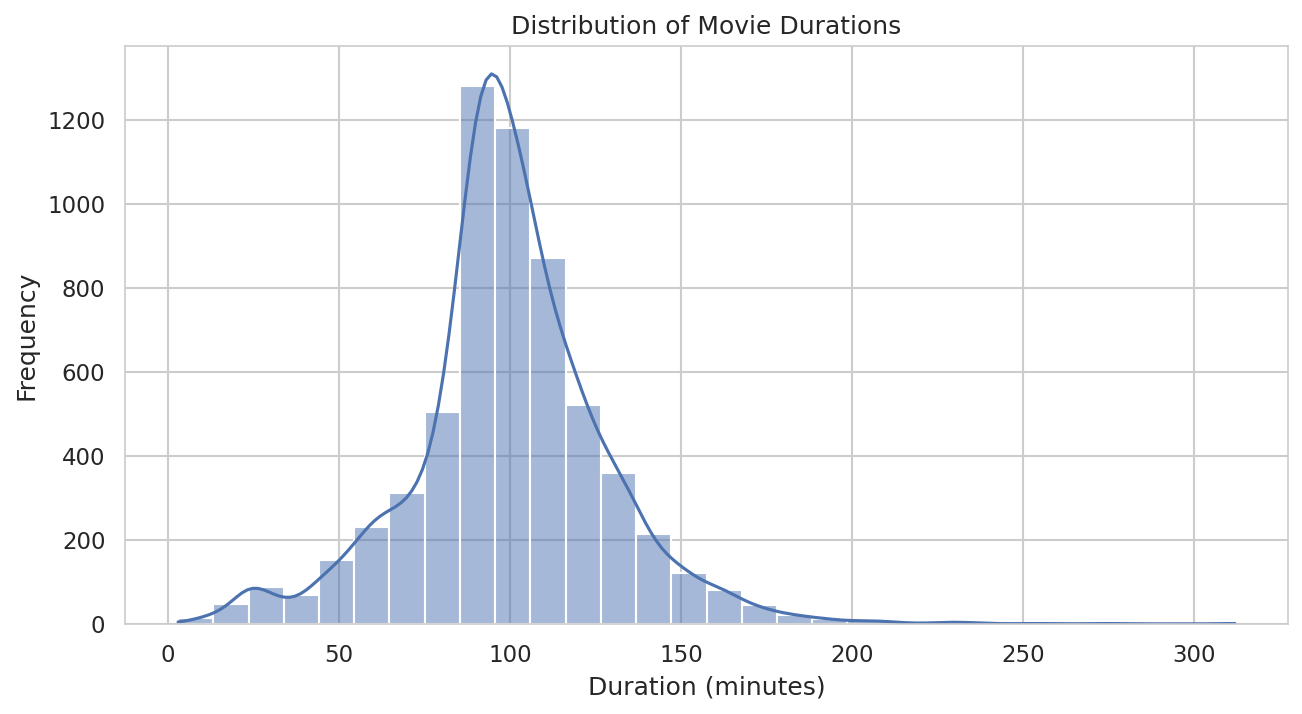

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_min'], bins=30, kde=True)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

Feature film durations follow an approximately normal distribution centered around a median of ~95–100 minutes, aligning with industry-standard viewer attention thresholds. The lower tail (<40 minutes) consists primarily of short films and animated specials, whereas the upper extreme (>150 minutes) is dominated by regional cinematic traditions, notably Indian feature cinema.

In [61]:
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['duration_season'] = pd.to_numeric(tv_shows['duration'].str.split(' ').str[0], errors = 'coerce')
tv_shows['duration_season'].describe()

,duration_season
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


In [62]:
tv_shows['duration_season'].value_counts()

,count
duration_season,
1,1793
2,425
3,199
4,95
5,65
6,33
7,23
8,17
9,9


/tmp/ipykernel_489/1685194788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='Blues_r')


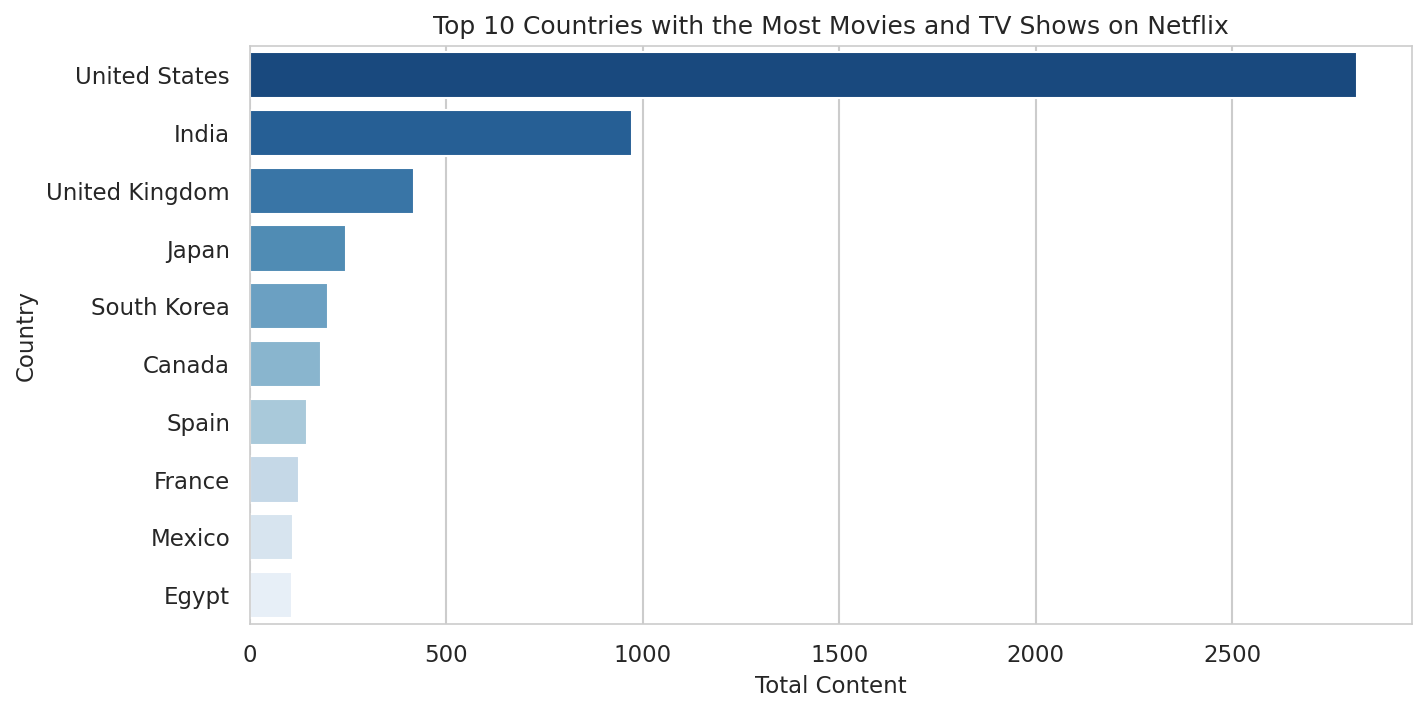

In [63]:
top_10_countries = df['country'].value_counts().drop('Unknown', errors='ignore').head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='Blues_r')
plt.title('Top 10 Countries with the Most Movies and TV Shows on Netflix')
plt.xlabel('Total Content', fontsize=11)
plt.ylabel('Country', fontsize=11)
plt.show()

The United States leads content output by a wide margin, reflecting the platform's domestic core. However, India's decisive position as the second-largest content contributor—alongside strong representation from the United Kingdom, Japan, and South Korea—underscores Netflix's strategic pivot toward regional localization and international subscriber acquisition.

In [64]:
top_genres = df_clean['listed_in'].str.split(', ').explode().value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [65]:
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean['month_added'] = df_clean['date_added'].dt.month_name()
df_clean['month_added'].value_counts()

,count
month_added,
July,819
December,797
September,765
April,759
October,755
August,749
March,734
January,727
June,724


In [66]:
df_clean['day_added'] = df_clean['date_added'].dt.day_name()
df_clean['day_added'].value_counts()

,count
day_added,
Friday,2476
Thursday,1387
Wednesday,1276
Tuesday,1182
Monday,845
Saturday,803
Sunday,740


Release scheduling exhibits a pronounced concentration on Fridays and Thursdays, designed to capture weekend streaming volume and support binge-watching behavior. Monthly release patterns peak in July and December, corresponding directly with holiday seasonality and heightened leisure screen time.